# Exploration of Harmonics on $[-\pi, \pi]$

This notebook visualizes how harmonics evolve from $k=1$ to $k=20$.

- Cell 2: Individual harmonics $\sin(kx)$ as a 4x5 gallery.
- Cell 3: Progressive harmonic development using a cumulative Fourier-style sum.

## How To Think About Modes

A mode is a standing wave that fits exactly in the interval.

For an interval $[-L, L]$ (length $2L$):

- Mode $k$ has $k$ full oscillations across the interval.
- Wavelength is $\lambda_k = \frac{2L}{k}$.
- Angular wavenumber is

$$
\omega_k = \frac{2\pi}{\lambda_k} = \frac{2\pi}{2L/k} = \frac{k\pi}{L}.
$$

So the harmonic basis becomes:

$$
\sin\!\left(\frac{k\pi x}{L}\right),\qquad \cos\!\left(\frac{k\pi x}{L}\right),\qquad k=1,2,\dots
$$

This is why changing the interval changes the frequency scale:

- On $[-\pi,\pi]$, $L=\pi$ so modes look like $\sin(kx),\cos(kx)$.
- On $[-\pi/2,\pi/2]$, $L=\pi/2$ so modes look like $\sin(2kx),\cos(2kx)$.

## Why $\pi/L > 1$ Still Gives Standing Waves

The factor $\pi/L$ sets **wavenumber spacing** (frequency in space), not amplitude.

- If $\pi/L > 1$ (so $L<\pi$), modes oscillate faster in $x$.
- If $\pi/L < 1$ (so $L>\pi$), modes oscillate slower in $x$.

For interval $[-L, L]$, mode $k$ is:

$$
\sin\!\left(\frac{k\pi x}{L}\right)
$$

This is still a valid standing wave because boundary values are satisfied exactly:

$$
\sin\!\left(\frac{k\pi(\pm L)}{L}\right) = \sin(\pm k\pi)=0,
$$
for every integer $k$.

So even when $\pi/L$ is large, the wave simply has shorter wavelength and more oscillations, while still fitting the interval endpoints correctly.

## String Harmonics vs Fourier Interval Convention

You are correct: for a fixed string, the first harmonic is a **half-wave shape** across the string length.

For a string of length $L_s$ with fixed ends at $x=0$ and $x=L_s$:

$$
y_n(x)=\sin\!\left(\frac{n\pi x}{L_s}\right),\quad n=1,2,\dots
$$

For $n=1$, this is half of a sine wave on $[0,L_s]$, so

$$
\lambda_1 = 2L_s.
$$

So the string length is half a wavelength in the fundamental mode.

Why this can look different in this notebook:

- Here we often use a symmetric interval $[-L,L]$ and the basis $\sin(k\pi x/L)$.
- On $[-L,L]$, the $k=1$ plot has two lobes (one positive, one negative), which visually resembles one full sine cycle over length $2L$.

Both descriptions are consistent; they use different interval conventions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Domain: x in [-pi, pi]
x = np.linspace(-np.pi, np.pi, 1500)
k_values = np.arange(1, 21)

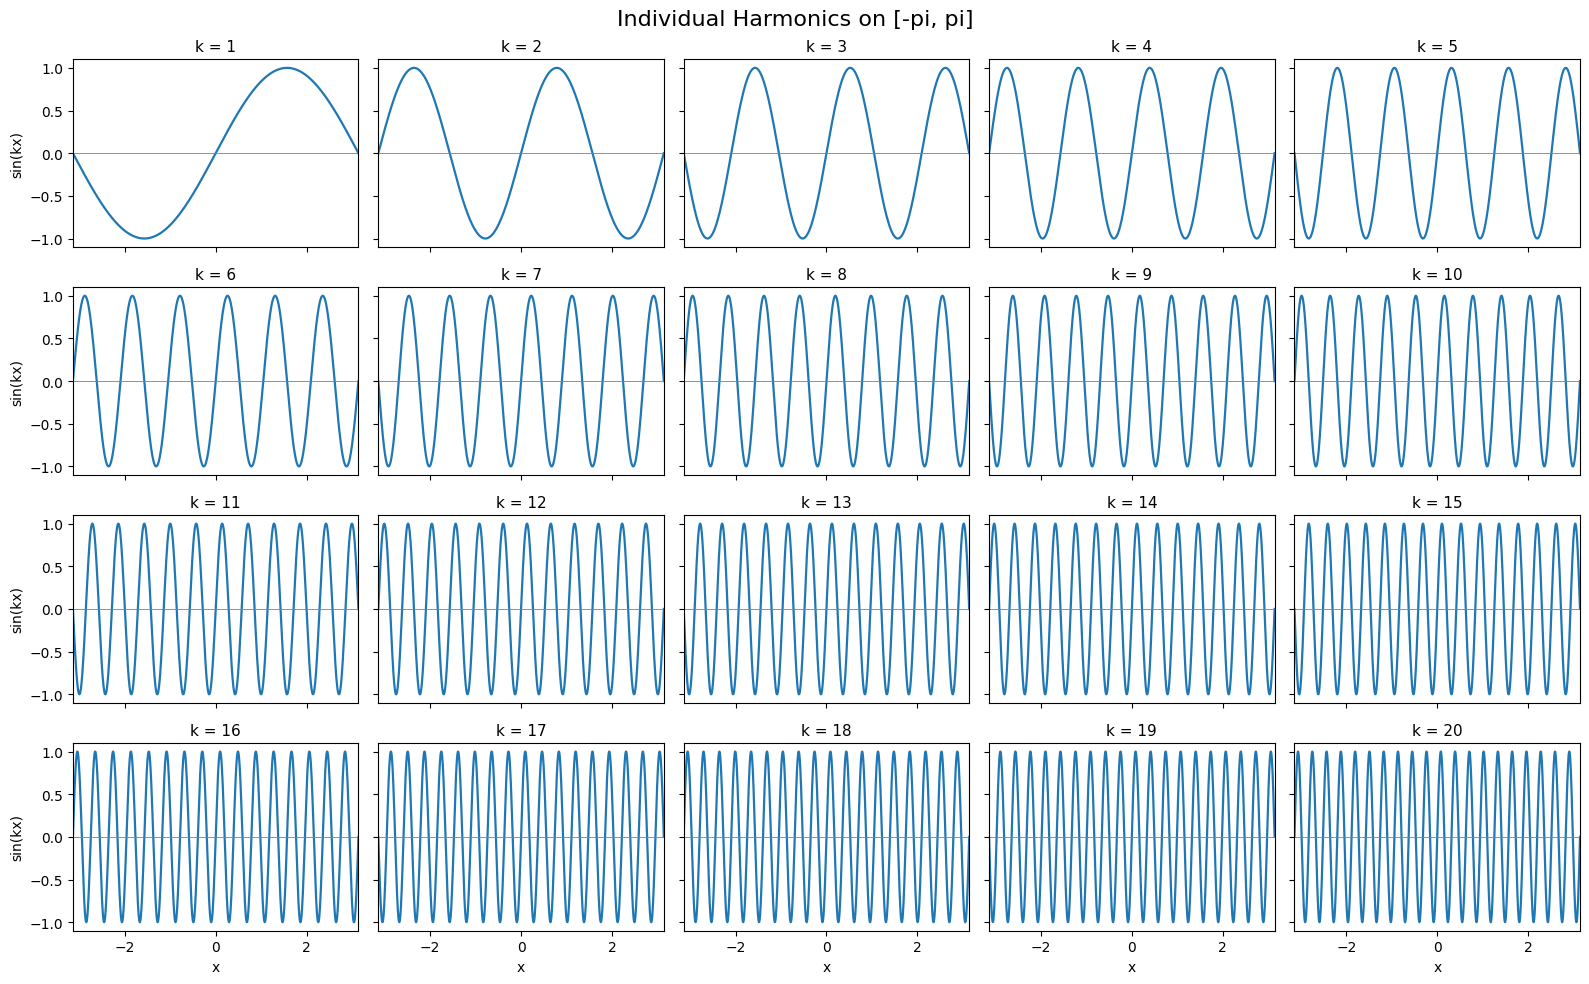

In [4]:
# 4x5 gallery: individual harmonics sin(kx), k=1..20
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, k in enumerate(k_values):
    y = np.sin(k * x)
    axes[i].plot(x, y, color='tab:blue', linewidth=1.6)
    axes[i].axhline(0, color='gray', linewidth=0.6)
    axes[i].set_title(f'k = {k}', fontsize=11)
    axes[i].set_xlim(-np.pi, np.pi)
    axes[i].set_ylim(-1.1, 1.1)

for ax in axes[15:]:
    ax.set_xlabel('x')
for ax in axes[::5]:
    ax.set_ylabel('sin(kx)')

fig.suptitle('Individual Harmonics on [-pi, pi]', fontsize=16)
plt.tight_layout()
plt.show()

## Note on Half-Wave Mode on $[-L, L]$

Yes. If one half-wave spans the full interval $[-L, L]$ (total length $2L$), then

$$
\lambda = 4L,
$$

so the spatial wavenumber is

$$
\kappa = \frac{2\pi}{\lambda} = \frac{2\pi}{4L} = \frac{\pi}{2L}.
$$

So your statement is correct in that sense.

Why this can look different from earlier cells:

- In this notebook we often used the basis $\sin(k\pi x/L)$, which has wavenumbers $\kappa_k = k\pi/L$.
- For a fixed-end string on $[-L, L]$ with only endpoint constraints at $x=\pm L$, the allowed family can be written with spacing $\pi/(2L)$, and the fundamental corresponds to the half-wave mode.

Both are valid descriptions; they come from different mode-index conventions and boundary-condition setups.

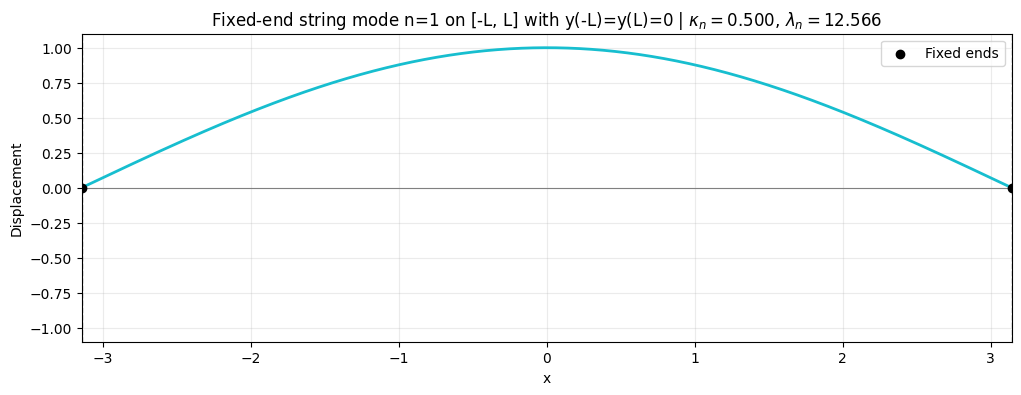

interactive(children=(FloatSlider(value=3.141592653589793, description='L', max=31.41592653589793, min=0.1), I…

In [ ]:
# Fixed-end string modes on interval [-L, L] (total length = 2L)
# Boundary conditions: y(-L)=0 and y(L)=0
# Allowed spatial wavenumbers: kappa_n = n*pi/(2L), n=1,2,...

from ipywidgets import FloatSlider, IntSlider, interact

def plot_fixed_end_string_mode(L, n):
    x_fixed = np.linspace(-L, L, 2000)

    # Shifted coordinate (x+L) maps [-L, L] -> [0, 2L]
    y_fixed = np.sin(n * np.pi * (x_fixed + L) / (2 * L))

    kappa_n = n * np.pi / (2 * L)
    lambda_n = 2 * np.pi / kappa_n  # = 4L/n

    plt.figure(figsize=(12, 4))
    plt.plot(x_fixed, y_fixed, color='tab:cyan', linewidth=2)
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(-L, color='gray', linestyle='--', linewidth=1)
    plt.axvline(L, color='gray', linestyle='--', linewidth=1)

    # Mark fixed endpoints (nodes)
    plt.scatter([-L, L], [0, 0], color='black', zorder=3, label='Fixed ends')

    plt.xlim(-L, L)
    plt.ylim(-1.1, 1.1)
    plt.xlabel('x')
    plt.ylabel('Displacement')
    plt.title(
        rf'Fixed-end string mode n={n} on [-L, L] with y(-L)=y(L)=0 | '
        rf'$\kappa_n={kappa_n:.3f}$, $\lambda_n={lambda_n:.3f}$'
    )
    plt.grid(alpha=0.25)
    plt.legend(loc='upper right')
    plt.show()

# Guaranteed preview when the cell is run
plot_fixed_end_string_mode(np.pi, 1)

interact(
    plot_fixed_end_string_mode,
    L=FloatSlider(value=np.pi, min=0.1, max=10*np.pi, step=0.1, description='L'),
    n=IntSlider(value=1, min=1, max=20, step=1, description='n')
);

## Key Takeaway

I understand that Fourier series for periodic functions uses a different eigenbasis than expansions with fixed boundary conditions.

- Periodic case on $[-L,L]$: basis functions are periodic with fundamental spacing $\pi/L$.
- Fixed-end string case on interval length $2L$: boundary constraints $y(-L)=y(L)=0$ lead to a different mode family, with fundamental spacing $\pi/(2L)$.

So the difference in mode formulas comes from different boundary conditions, not a contradiction.

## Dirichlet Eigenbasis on $[-L, L]$ with $f(-L)=f(L)=0$

For the Dirichlet boundary-value problem on $[-L,L]$, a convenient orthogonal eigenbasis is

$$
\phi_n(x)=\sin\!\left(\frac{n\pi(x+L)}{2L}\right),\qquad n=1,2,3,\dots
$$

These satisfy the endpoint conditions exactly:

$$
\phi_n(-L)=0,\qquad \phi_n(L)=\sin(n\pi)=0.
$$

So any sufficiently regular function with homogeneous Dirichlet data can be expanded in this basis.

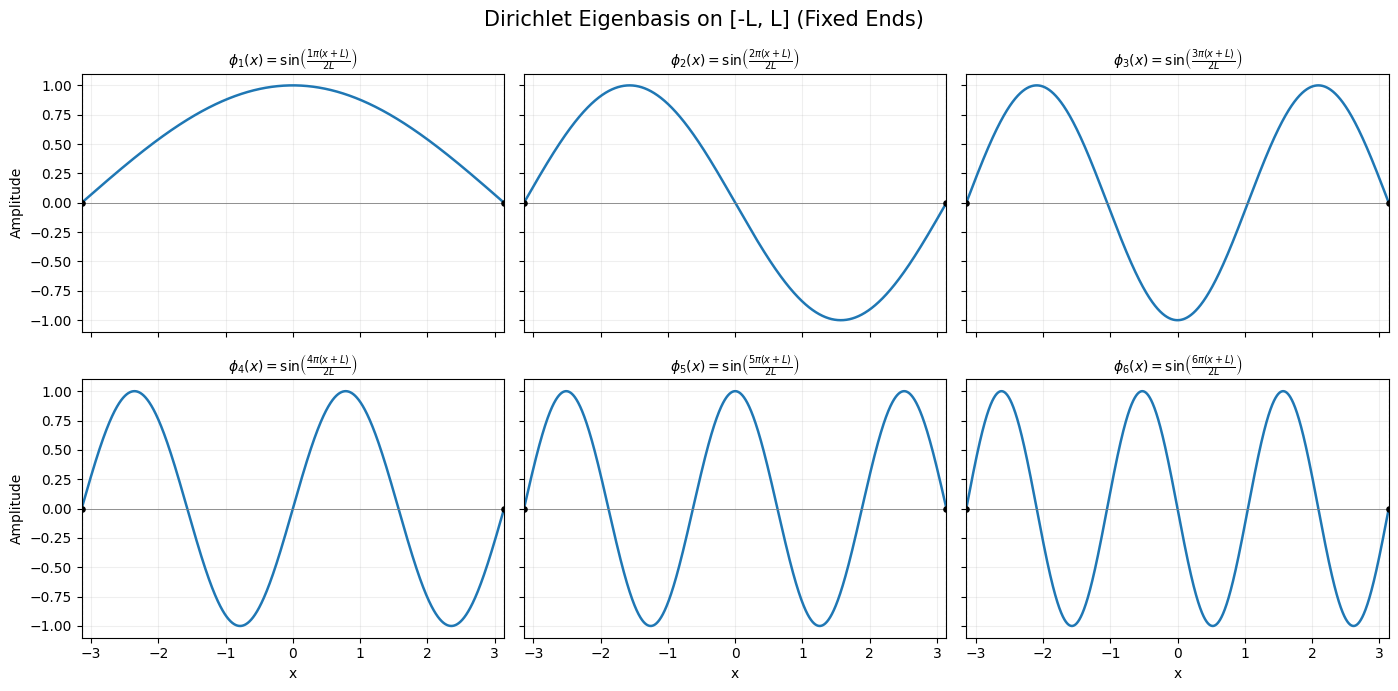

In [18]:
# Visualize first Dirichlet eigenbasis functions on [-L, L]
L_dir = np.pi
x_dir = np.linspace(-L_dir, L_dir, 2000)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()

for idx, n in enumerate(range(1, 7)):
    phi_n = np.sin(n * np.pi * (x_dir + L_dir) / (2 * L_dir))
    axes[idx].plot(x_dir, phi_n, color='tab:blue', linewidth=1.8)
    axes[idx].axhline(0, color='gray', linewidth=0.6)
    axes[idx].axvline(-L_dir, color='gray', linestyle='--', linewidth=0.8)
    axes[idx].axvline(L_dir, color='gray', linestyle='--', linewidth=0.8)
    axes[idx].scatter([-L_dir, L_dir], [0, 0], color='black', s=14, zorder=3)
    axes[idx].set_title(rf'$\phi_{{{n}}}(x)=\sin\!\left(\frac{{{n}\pi(x+L)}}{{2L}}\right)$', fontsize=10)
    axes[idx].set_xlim(-L_dir, L_dir)
    axes[idx].set_ylim(-1.1, 1.1)
    axes[idx].grid(alpha=0.2)

for ax in axes[3:]:
    ax.set_xlabel('x')
for ax in axes[::3]:
    ax.set_ylabel('Amplitude')

fig.suptitle('Dirichlet Eigenbasis on [-L, L] (Fixed Ends)', fontsize=15)
plt.tight_layout()
plt.show()

## Neumann Boundary Conditions on $[-L, L]$

For the Neumann case, the derivative is fixed at the endpoints:

$$
f'(-L)=f'(L)=0.
$$

Physically, this means zero slope at the boundaries (free ends / zero flux, depending on the model).

A convenient eigenbasis on $[-L,L]$ is

$$
\psi_n(x)=\cos\!\left(\frac{n\pi(x+L)}{2L}\right),\qquad n=0,1,2,\dots
$$

with

$$
\psi_n'(-L)=\psi_n'(L)=0.
$$

Notes:

- The $n=0$ mode is the constant mode (zero eigenvalue).
- For $n\ge 1$, these are oscillatory Neumann modes.
- This differs from Dirichlet, where the function value is pinned to zero at the endpoints instead of its derivative.

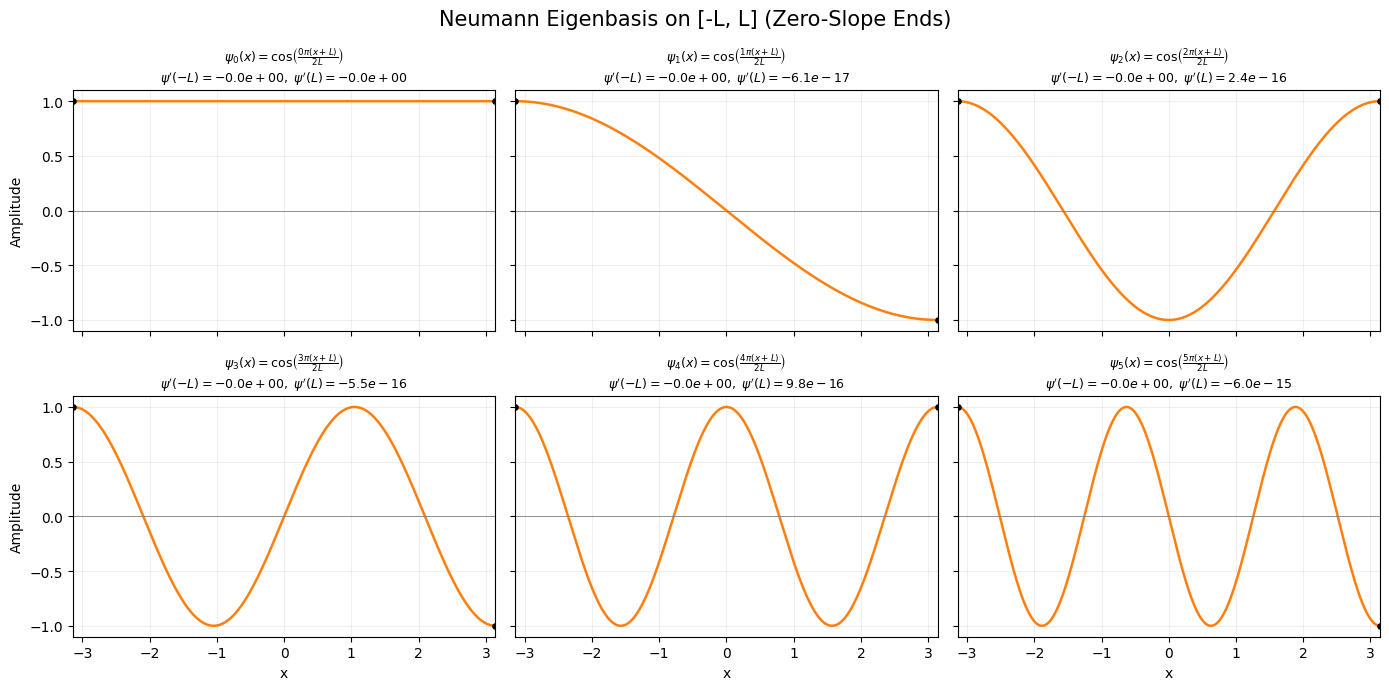

In [20]:
# Visualize first Neumann eigenbasis functions on [-L, L]
L_neu = np.pi
x_neu = np.linspace(-L_neu, L_neu, 2000)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()

for idx, n in enumerate(range(0, 6)):
    psi_n = np.cos(n * np.pi * (x_neu + L_neu) / (2 * L_neu))

    # Derivative: psi_n'(x) = -(n*pi/(2L)) sin(n*pi(x+L)/(2L))
    dpsi_left = -(n * np.pi / (2 * L_neu)) * np.sin(n * np.pi * (-L_neu + L_neu) / (2 * L_neu))
    dpsi_right = -(n * np.pi / (2 * L_neu)) * np.sin(n * np.pi * (L_neu + L_neu) / (2 * L_neu))

    axes[idx].plot(x_neu, psi_n, color='tab:orange', linewidth=1.8)
    axes[idx].axhline(0, color='gray', linewidth=0.6)
    axes[idx].axvline(-L_neu, color='gray', linestyle='--', linewidth=0.8)
    axes[idx].axvline(L_neu, color='gray', linestyle='--', linewidth=0.8)
    axes[idx].scatter([-L_neu, L_neu], [psi_n[0], psi_n[-1]], color='black', s=14, zorder=3)

    axes[idx].set_title(
        rf'$\psi_{{{n}}}(x)=\cos\!\left(\frac{{{n}\pi(x+L)}}{{2L}}\right)$' + '\n'
        + rf"$\psi'(-L)={dpsi_left:.1e},\ \psi'(L)={dpsi_right:.1e}$",
        fontsize=9
    )
    axes[idx].set_xlim(-L_neu, L_neu)
    axes[idx].set_ylim(-1.1, 1.1)
    axes[idx].grid(alpha=0.2)

for ax in axes[3:]:
    ax.set_xlabel('x')
for ax in axes[::3]:
    ax.set_ylabel('Amplitude')

fig.suptitle('Neumann Eigenbasis on [-L, L] (Zero-Slope Ends)', fontsize=15)
plt.tight_layout()
plt.show()

## What Is the Fourier Transform Curve?

**FT** stands for **Fourier Transform**. The "FT curve" in the right panel of the next cell is the continuous Fourier transform of $f(x) = e^{-x^2/2}$:

$$
F(\omega) = \int_{-\infty}^{\infty} f(x)\, e^{-i\omega x}\, dx = \sqrt{2\pi}\; e^{-\omega^2/2}.
$$

Key ideas:

- The FT maps a function of **position** $x$ into a function of **frequency** $\omega$, revealing how much of each frequency is present in the signal.
- For a Gaussian input, the FT is itself a Gaussian — Gaussians are eigenfunctions of the Fourier transform.
- The **Fourier series** on $[-L, L]$ gives *discrete* samples at $\omega_k = k\pi/L$, related to the FT by

$$
F(\omega_k) \approx 2L\, c_k.
$$

- As $L \to \infty$, the spacing $\Delta\omega = \pi/L \to 0$, so the discrete FS samples get denser and converge to the continuous FT curve.

This convergence — **discrete $\to$ continuous** — is exactly what the interactive cell below visualizes.


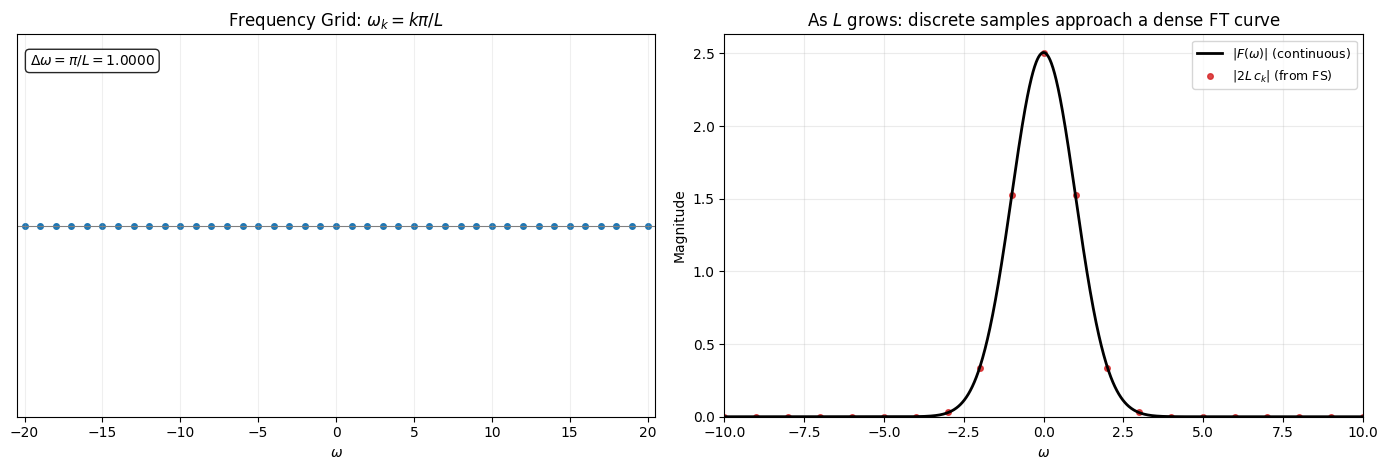

interactive(children=(FloatSlider(value=3.141592653589793, description='L', max=40.0, min=1.0, step=1.0), IntS…

In [ ]:
# Fourier series -> Fourier transform as L -> infinity
# Demo with f(x)=exp(-x^2/2): F(omega)=sqrt(2*pi)*exp(-omega^2/2)
# On [-L, L], FS frequencies are omega_k = k*pi/L and Delta_omega = pi/L.
# The transform samples are approximated by: F(omega_k) ~ 2L * c_k.

from ipywidgets import interact, FloatSlider, IntSlider

def fs_to_ft_limit_demo(L, kmax):
    x = np.linspace(-L, L, 3000)
    f = np.exp(-0.5 * x**2)

    k_vals = np.arange(-kmax, kmax + 1)
    omega_k = k_vals * np.pi / L

    # Compute I_k = integral_{-L}^{L} f(x) * exp(-i*omega_k*x) dx
    phase = np.exp(-1j * np.outer(omega_k, x))
    I_k = np.trapezoid(phase * f, x, axis=1)

    # FS coefficients on [-L, L]
    c_k = I_k / (2 * L)

    # Transform samples recovered from FS coefficients
    Fk_from_fs = 2 * L * c_k

    # Continuous transform (analytic for Gaussian)
    omega_plot = np.linspace(-10, 10, 1600)
    F_cont = np.sqrt(2 * np.pi) * np.exp(-0.5 * omega_plot**2)

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

    # Panel 1: frequency grid density
    axs[0].scatter(omega_k, np.zeros_like(omega_k), s=16, color='tab:blue')
    axs[0].axhline(0, color='gray', linewidth=0.8)
    axs[0].set_title(r'Frequency Grid: $\omega_k = k\pi/L$')
    axs[0].set_xlabel(r'$\omega$')
    axs[0].set_yticks([])
    axs[0].set_xlim(min(-10, omega_k.min() - 0.5), max(10, omega_k.max() + 0.5))
    axs[0].grid(alpha=0.2)
    axs[0].text(
        0.02,
        0.92,
        rf'$\Delta\omega=\pi/L={np.pi/L:.4f}$',
        transform=axs[0].transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    # Panel 2: FS samples vs continuous FT
    axs[1].plot(omega_plot, np.abs(F_cont), color='black', linewidth=2, label=r'$|F(\omega)|$ (continuous)')
    axs[1].scatter(omega_k, np.abs(Fk_from_fs), s=16, color='tab:red', alpha=0.85, label=r'$|2L\,c_k|$ (from FS)')
    axs[1].set_title(r'As $L$ grows: discrete samples approach a dense FT curve')
    axs[1].set_xlabel(r'$\omega$')
    axs[1].set_ylabel('Magnitude')
    axs[1].set_xlim(-10, 10)
    axs[1].set_ylim(bottom=0)
    axs[1].grid(alpha=0.25)
    axs[1].legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

# Guaranteed preview on execution
fs_to_ft_limit_demo(np.pi, 20)

interact(
    fs_to_ft_limit_demo,
    L=FloatSlider(value=np.pi, min=1.0, max=40.0, step=1.0, description='L'),
    kmax=IntSlider(value=20, min=5, max=80, step=1, description='kmax')
);